In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [ ]:
# 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [ ]:
# 2. Normalize (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Reshape for CNN (Add channel dimension)

In [ ]:

# 3. Reshape for CNN (Add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
# 4. Build CNN Modelbuilding the model
model = models.Sequential([

    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 6. Model Summary
model.summary()

# 7. Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 26, 26, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 3, 3, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 60,874 (237.79 KB)

 Trainable params: 60,874 (237.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9317 - loss: 0.2303 - val_accuracy: 0.9797 - val_loss: 0.0711
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9806 - loss: 0.0623 - val_accuracy: 0.9800 - val_loss: 0.0677
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9861 - loss: 0.0438 - val_accuracy: 0.9864 - val_loss: 0.0468
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9886 - loss: 0.0351 - val_accuracy: 0.9870 - val_loss: 0.0427
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9907 - loss: 0.0280 - val_accuracy: 0.9859 - val_loss: 0.0474


In [ ]:

# 8. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9900 - loss: 0.0321

Test Accuracy: 0.9900000095367432


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


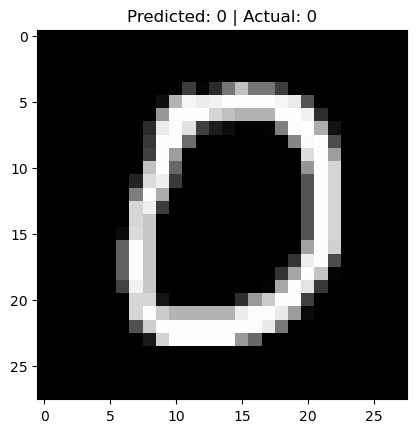

In [ ]:



# 9. Predict One Image
predictions = model.predict(x_test)


plt.imshow(x_test[10].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predictions[10].argmax()} | Actual: {y_test[10]}")
plt.show()


In [ ]:
import numpy as np
y_pred_class=np.argmax(predictions,axis=1)


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_class)
print(cm)

[[ 977    0    0    0    0    0    2    1    0    0]
 [   0 1131    1    2    0    0    0    0    0    1]
 [   4    2 1023    0    0    0    0    2    1    0]
 [   1    0    2  999    0    4    0    0    3    1]
 [   0    0    0    1  975    0    1    0    0    5]
 [   3    0    0   11    0  868    1    1    2    6]
 [   6    2    0    0    2    1  946    0    1    0]
 [   0    5    4    3    2    0    0  993    2   19]
 [   3    0    0    0    0    0    0    0  965    6]
 [   2    0    0    1    4    4    1    0    0  997]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.97      0.98       892
           6       0.99      0.99      0.99       958
           7       1.00      0.97      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.96      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

